<a href="https://colab.research.google.com/github/SuleimanAlbalkhi/explainable-pistol-detection/blob/main/CNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, accuracy_score, average_precision_score


In [ ]:
!unzip /content/cls_Dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: cls_Dataset/train/no_pistol/58a9ab61609f3ba3.jpg  
  inflating: cls_Dataset/train/no_pistol/58b04d42f87cd744.jpg  
  inflating: cls_Dataset/train/no_pistol/58b9029584651f77.jpg  
  inflating: cls_Dataset/train/no_pistol/58becd95c55c03bd.jpg  
  inflating: cls_Dataset/train/no_pistol/58c8e6e5fdb33911.jpg  
  inflating: cls_Dataset/train/no_pistol/58d2eca26bb45d2f.jpg  
  inflating: cls_Dataset/train/no_pistol/58e0711ca542b8ff.jpg  
  inflating: cls_Dataset/train/no_pistol/58f838bff096ca03.jpg  
  inflating: cls_Dataset/train/no_pistol/590995519674d4a1.jpg  
  inflating: cls_Dataset/train/no_pistol/5924b01dc6c9515d.jpg  
  inflating: cls_Dataset/train/no_pistol/593b7614a431388b.jpg  
  inflating: cls_Dataset/train/no_pistol/59a533dc0453f1b4.jpg  
  inflating: cls_Dataset/train/no_pistol/59bbb58983b864af.jpg  
  inflating: cls_Dataset/train/no_pistol/59d96e1c937e74ae.jpg  
  inflating: cls_Dataset/train/no_pistol/5a1943e275e7

In [ ]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((416, 416)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transform = transforms.Compose([
    transforms.Resize((416, 416)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

data_dir = "/content/cls_Dataset"

train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(root=os.path.join(data_dir, "val"),   transform=val_transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("📁 Klassen:", train_dataset.classes)
print("📊 Train-Bilder:", len(train_dataset), "| Val-Bilder:", len(val_dataset))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Verwendetes Gerät: {device}")

📁 Klassen: ['no_pistol', 'pistol']
📊 Train-Bilder: 4778 | Val-Bilder: 1194
💻 Verwendetes Gerät: cuda


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class PistolDetectionCNN(nn.Module):
    def __init__(self, num_classes=2, lr=0.001, weight_decay=5e-4):
        super().__init__()

        # --- Block 1 ---
        self.ConvLayer1 = nn.Conv2d(3, 16, 3, padding=1)
        self.BN1 = nn.BatchNorm2d(16)
        self.ReLU1 = nn.ReLU(inplace=True)
        self.Pool1 = nn.MaxPool2d(2, 2)

        # --- Block 2 ---
        self.ConvLayer2 = nn.Conv2d(16, 32, 3, padding=1)
        self.BN2 = nn.BatchNorm2d(32)
        self.ReLU2 = nn.ReLU(inplace=True)
        self.Pool2 = nn.MaxPool2d(2, 2)

        # --- Block 3 ---
        self.ConvLayer3 = nn.Conv2d(32, 64, 3, padding=1)
        self.BN3 = nn.BatchNorm2d(64)
        self.ReLU3 = nn.ReLU(inplace=True)
        self.Pool3 = nn.MaxPool2d(2, 2)

        # --- Block 4 ---
        self.ConvLayer4 = nn.Conv2d(64, 128, 3, padding=1)
        self.BN4 = nn.BatchNorm2d(128)
        self.ReLU4 = nn.ReLU(inplace=True)
        self.Pool4 = nn.MaxPool2d(2, 2)

        # --- Block 5 ---
        self.ConvLayer5 = nn.Conv2d(128, 256, 3, padding=1)
        self.BN5 = nn.BatchNorm2d(256)
        self.ReLU5 = nn.ReLU(inplace=True)
        self.Pool5 = nn.MaxPool2d(2, 2)

        # --- Block 6 (neu, 416 Filter) ---
        self.ConvLayer6 = nn.Conv2d(256, 416, 3, padding=1)
        self.BN6 = nn.BatchNorm2d(416)
        self.ReLU6 = nn.ReLU(inplace=True)
        self.Pool6 = nn.MaxPool2d(2, 2)

        # --- Klassifikationskopf ---
        self.GlobalPool = nn.AdaptiveAvgPool2d(1)
        self.Flatten = nn.Flatten()
        self.FC1 = nn.Linear(416, 128)
        self.ReLU_fc = nn.ReLU(inplace=True)
        self.Dropout = nn.Dropout(0.1)
        self.FC2 = nn.Linear(128, num_classes)

        # --- Trainingseinstellungen ---
        self.learning_rate = lr
        self.Criterion = nn.CrossEntropyLoss()
        self.Optimizer = optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)
        self.Scheduler = optim.lr_scheduler.ReduceLROnPlateau(self.Optimizer, mode='max', factor=0.5, patience=3)
        self.history = {"train_loss": [], "val_loss": [], "val_accuracy": [], "val_recall": [], "val_precision": [], "val_mAP": []}

        # --- Initialisierung ---
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

    # Für spätere Stufen (UNet/SSD/YOLO)
    def forward_features(self, x):
        x = self.Pool1(self.ReLU1(self.BN1(self.ConvLayer1(x)))); c1 = x
        x = self.Pool2(self.ReLU2(self.BN2(self.ConvLayer2(x)))); c2 = x
        x = self.Pool3(self.ReLU3(self.BN3(self.ConvLayer3(x)))); c3 = x
        x = self.Pool4(self.ReLU4(self.BN4(self.ConvLayer4(x)))); c4 = x
        x = self.Pool5(self.ReLU5(self.BN5(self.ConvLayer5(x)))); c5 = x
        x = self.Pool6(self.ReLU6(self.BN6(self.ConvLayer6(x)))); c6 = x
        return c1, c2, c3, c4, c5, c6


    def forward(self, x):
        _, _, _, _, _, x = self.forward_features(x)
        x = self.GlobalPool(x)
        x = self.Flatten(x)
        x = self.ReLU_fc(self.FC1(x))
        x = self.Dropout(x)
        x = self.FC2(x)
        return x


    # 1 Trainingsschritt
    def train_step(self, inputs, labels):
        self.Optimizer.zero_grad(set_to_none=True)
        outputs = self.forward(inputs)
        loss = self.Criterion(outputs, labels)
        loss.backward()
        self.Optimizer.step()
        return loss.item()


    # Evaluierung (Accuracy, Recall, Precision, mAP)

    def evaluate_metrics(self, data_loader, device):
        self.eval()
        all_preds, all_labels, all_probs = [], [], []
        total_loss = 0.0
        with torch.no_grad():
            for inputs, labels in data_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = self.forward(inputs)
                loss = self.Criterion(outputs, labels)
                total_loss += loss.item() * inputs.size(0)
                probs = torch.softmax(outputs, dim=1)[:, 1]
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        avg_loss = total_loss / len(data_loader.dataset)
        acc = accuracy_score(all_labels, all_preds)
        rec = recall_score(all_labels, all_preds, average="binary")
        prec = precision_score(all_labels, all_preds, average="binary")
        try:
            mAP = average_precision_score(all_labels, all_probs)
        except:
            mAP = 0.0

        self.train()
        return avg_loss, acc * 100, rec * 100, prec * 100, mAP * 100


    # Training mit Early Stopping

    def train_model(self, train_loader, val_loader, epochs=20, device='cpu', early_stop_patience=7):
        self.to(device)
        best_acc = -1.0
        epochs_no_improve = 0

        for epoch in range(epochs):
            start_time = time.time()
            self.train()
            running_loss = 0.0

            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                loss = self.train_step(inputs, labels)
                running_loss += loss * inputs.size(0)

            train_loss = running_loss / len(train_loader.dataset)
            self.history["train_loss"].append(train_loss)

            val_loss, val_acc, val_recall, val_prec, val_map = self.evaluate_metrics(val_loader, device)
            self.history["val_loss"].append(val_loss)
            self.history["val_accuracy"].append(val_acc)
            self.history["val_recall"].append(val_recall)
            self.history["val_precision"].append(val_prec)
            self.history["val_mAP"].append(val_map)

            self.Scheduler.step(val_acc)

            # --- Early Stopping ---
            if val_acc > best_acc:
                best_acc = val_acc
                epochs_no_improve = 0
                best_state = {k: v.cpu().clone() for k, v in self.state_dict().items()}
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= early_stop_patience:
                    print(f" Early Stop nach {epoch+1} Epochen – beste Val-Acc: {best_acc:.2f}%")
                    self.load_state_dict(best_state)
                    self.to(device)
                    return self.history

            epoch_time = time.time() - start_time
            print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {val_acc:.2f}% | "
                  f"Recall: {val_recall:.2f}% | Prec: {val_prec:.2f}% | mAP: {val_map:.2f}% | Time: {epoch_time:.2f}s")

        if 'best_state' in locals():
            self.load_state_dict(best_state)
            self.to(device)
        return self.history

In [ ]:
#Initialisieren & Trainieren
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print (f"Verwendetes Gerät:{device}")

model = PistolDetectionCNN(num_classes=len(train_dataset.classes), lr=0.0005)
history = model.train_model(train_loader, val_loader, epochs=40, device=device, early_stop_patience=5)

def get_device_data(data, target):
  return data.to(device), target.to(device)

Verwendetes Gerät:cuda
Epoch 1/40 | Loss: 0.4551 | Val Loss: 0.3649 | Acc: 85.01% | Recall: 91.46% | Prec: 81.01% | mAP: 92.32% | Time: 91.64s
Epoch 2/40 | Loss: 0.3107 | Val Loss: 0.2625 | Acc: 88.78% | Recall: 83.42% | Prec: 93.43% | mAP: 96.96% | Time: 88.74s
Epoch 3/40 | Loss: 0.2563 | Val Loss: 0.1759 | Acc: 93.63% | Recall: 95.98% | Prec: 91.68% | mAP: 98.32% | Time: 87.10s
Epoch 4/40 | Loss: 0.2007 | Val Loss: 0.1531 | Acc: 94.14% | Recall: 92.13% | Prec: 95.99% | mAP: 98.79% | Time: 87.64s
Epoch 5/40 | Loss: 0.1852 | Val Loss: 0.1613 | Acc: 93.38% | Recall: 98.32% | Prec: 89.48% | mAP: 99.26% | Time: 87.71s
Epoch 6/40 | Loss: 0.1531 | Val Loss: 0.1542 | Acc: 94.22% | Recall: 98.49% | Prec: 90.74% | mAP: 99.25% | Time: 86.65s
Epoch 7/40 | Loss: 0.1499 | Val Loss: 0.1328 | Acc: 94.81% | Recall: 98.49% | Prec: 91.73% | mAP: 99.43% | Time: 86.52s
Epoch 8/40 | Loss: 0.1484 | Val Loss: 0.5173 | Acc: 76.05% | Recall: 99.83% | Prec: 67.65% | mAP: 99.01% | Time: 87.50s
Epoch 9/40 | Loss

In [ ]:
from google.colab import files

# Save the model's state dictionary
torch.save(model.state_dict(), 'pistol_detection_cnn.pth')

# Download the saved model file
files.download('pistol_detection_cnn.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
loaded_model = PistolDetectionCNN(num_classes=len(train_dataset.classes))
loaded_model.load_state_dict(torch.load('/content/pistol_detection_cnn.pth', map_location=torch.device('cpu')))
loaded_model.to(device)
print("Model loaded successfully!")

Model loaded successfully!


Validation Accuracy: 0.04%

Example Predictions from Validation Set:


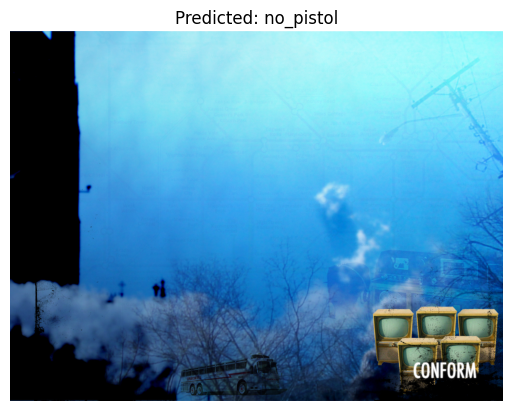

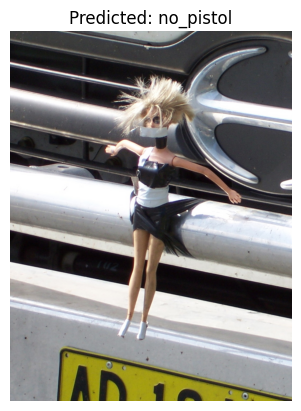

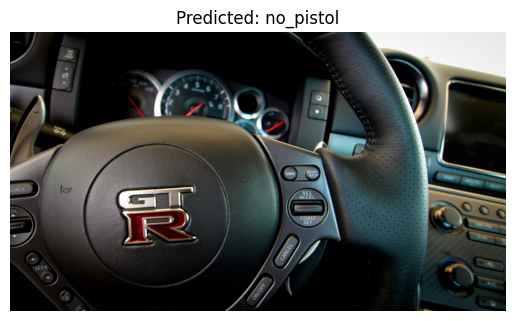

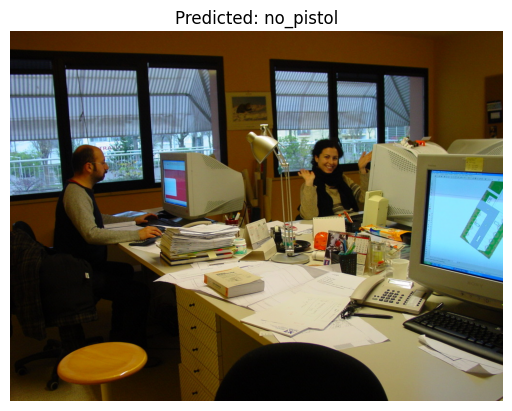

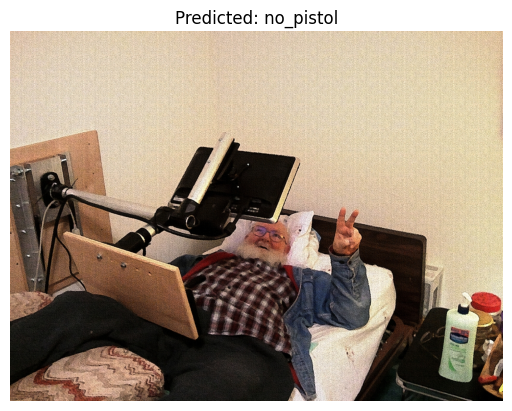

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random # Import the random module

# Evaluate the model on the validation set
val_metrics = loaded_model.evaluate_metrics(val_loader, device=device)
val_accuracy = val_metrics[0] # Extract accuracy from the tuple
print(f"Validation Accuracy: {val_accuracy:.2f}%")

# Function to display image and prediction
def show_prediction(model, image_path, device, transform, classes):
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.inference_mode():
        outputs = model(image_tensor)
        _, predicted = torch.max(outputs, 1)
        predicted_class = classes[predicted.item()]

    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()

# Display a few example images with predictions from the validation set
print("\nExample Predictions from Validation Set:")
# Get a list of all image paths in the validation set
all_val_image_paths = []
for label_dir in os.listdir(os.path.join(data_dir, "val")):
    label_path = os.path.join(data_dir, "val", label_dir)
    if os.path.isdir(label_path):
        for image_name in os.listdir(label_path):
            all_val_image_paths.append(os.path.join(label_path, image_name))

# Shuffle the list and take the first 5 images
random.shuffle(all_val_image_paths)
example_image_paths = all_val_image_paths[:5]


for img_path in example_image_paths:
    show_prediction(loaded_model, img_path, device, val_transform, val_dataset.classes)

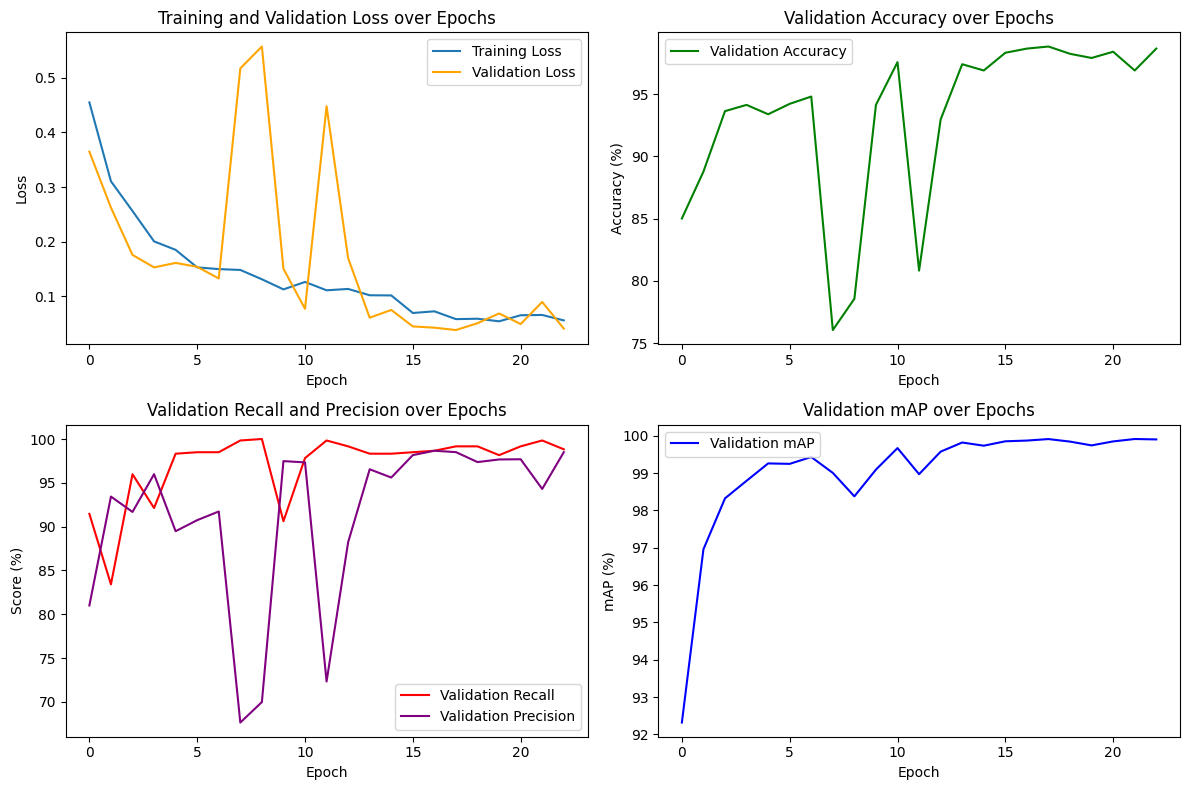

In [ ]:
plt.figure(figsize=(12, 8))

# Plotting Training Loss and Validation Loss
plt.subplot(2, 2, 1)
plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss", color="orange")
plt.title("Training and Validation Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plotting Validation Accuracy
plt.subplot(2, 2, 2)
plt.plot(history["val_accuracy"], label="Validation Accuracy", color="green")
plt.title("Validation Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

# Plotting Validation Recall and Precision
plt.subplot(2, 2, 3)
plt.plot(history["val_recall"], label="Validation Recall", color="red")
plt.plot(history["val_precision"], label="Validation Precision", color="purple")
plt.title("Validation Recall and Precision over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Score (%)")
plt.legend()

# Plotting Validation mAP
plt.subplot(2, 2, 4)
plt.plot(history["val_mAP"], label="Validation mAP", color="blue")
plt.title("Validation mAP over Epochs")
plt.xlabel("Epoch")
plt.ylabel("mAP (%)")
plt.legend()

plt.tight_layout()
plt.show()